# ![Machine Learning Lab](banner.jpg)

# Laboratorio 7 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab7.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar un Perceptrón Multicapa (MLP) para clasificación multiclase.
2. Implementar el mismo modelo en dos frameworks: **PyTorch** y **TensorFlow/Keras**.
3. Evaluar y comparar el desempeño de ambos modelos.

---

En esta ocasión trabajaremos con el dataset **Blood Cell Anomaly Detection 2025**, que contiene 5,880 registros de células sanguíneas con 36 características morfológicas, clínicas y de adquisición. El objetivo es clasificar cada registro en uno de los **19 tipos de célula** disponibles.

Dataset: [Blood Cell Anomaly Detection 2025](https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el archivo `blood_cell_anomaly_detection.csv` desde Kaggle.
2. Carga el CSV en un DataFrame y muestra las primeras filas.
3. Identifica la columna objetivo (`cell_type`) y muestra la distribución de las 19 clases.
4. ¿Cuántas características numéricas y categóricas tiene el dataset? ¿Hay valores faltantes?

---

### 2. Preprocesamiento de datos (20%)

Las siguientes columnas **no deben usarse** como features: `anomaly_label`, `disease_category`, `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score`.

1. Elimina las columnas mencionadas y el identificador (`cell_id`).
2. Normaliza las features numéricas (escalar al rango [0,1] o estandarizar).
3. Aplica **one-hot encoding** a las features categóricas y combínalas con las numéricas.
4. Codifica la columna objetivo (`cell_type`) como valores numéricos.
5. Divide los datos en conjunto de entrenamiento (80%) y prueba (20%). Utiliza `random_state = 42`

---

### 3. MLP con PyTorch (30%)

1. Convierte los datos de entrenamiento y prueba a tensores de PyTorch y crea DataLoaders.
2. Construye un MLP usando `nn.Module` con al menos 2 capas ocultas y activación ReLU.
3. ¿Cuántos parámetros tiene la red? Muestra la cantidad de parametros por cada capa.
4. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
5. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 4. MLP con TensorFlow/Keras (30%)

1. Construye un MLP equivalente al anterior usando la API Sequential de Keras.
2. Compila el modelo con el optimizador y función de pérdida adecuados.
3. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
4. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 5. Comparación de resultados (10%)

1. Genera la matriz de confusión para los modelos MLP.
2. ¿Cuáles tipos de célula son más difíciles de clasificar? ¿Son los mismos en ambos modelos?
3. Compara la precisión obtenida con PyTorch vs TensorFlow.

---


In [801]:
# librerias 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch import device
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers

In [802]:
# dispositivo para PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: mps


### 1. Carga y exploración de datos (10%)

1. Descarga el archivo `blood_cell_anomaly_detection.csv` desde Kaggle.
2. Carga el CSV en un DataFrame y muestra las primeras filas.
3. Identifica la columna objetivo (`cell_type`) y muestra la distribución de las 19 clases.
4. ¿Cuántas características numéricas y categóricas tiene el dataset? ¿Hay valores faltantes?


In [803]:
# cargar el csv y mostrar las primeras filas
cell_anomaly_df = pd.read_csv('datasets/blood_cell_anomaly_detection.csv')
print(f'Número de filas: {cell_anomaly_df.shape[0]}')
print(f'Número de columnas: {cell_anomaly_df.shape[1]}')
cell_anomaly_df.head()

Número de filas: 5880
Número de columnas: 36


,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


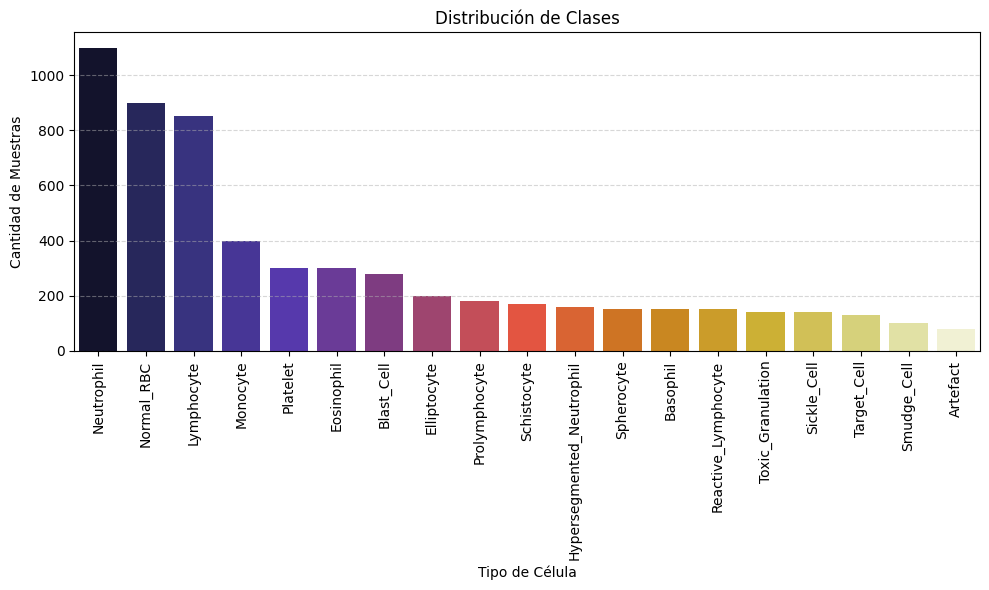

In [804]:
# graficar la distribución de clases
counts = cell_anomaly_df['cell_type'].value_counts()
df_sorted = counts.reset_index()
df_sorted.columns = ['cell_type', 'cantidad']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='cell_type', y='cantidad', data=df_sorted, palette='CMRmap', hue='cell_type')
plt.title('Distribución de Clases')
plt.xlabel('Tipo de Célula')
plt.ylabel('Cantidad de Muestras')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Se puede notar un notorio desbalance en las distribución de las clases, lo que podría afectar el desempeño de los modelos.

In [805]:
# caracterización del dataset
# excluir el id para
cell_anomaly_df = cell_anomaly_df.drop(columns=['cell_id'])
# identificar caracteristicas numéricas y categóricas 
numerical_features = cell_anomaly_df.select_dtypes(include=['number']).columns
categorical_features = cell_anomaly_df.select_dtypes(include=['object']).columns

print("Número de características numéricas:", len(numerical_features))
print("Características numéricas:", numerical_features.tolist())
print("Número de características categóricas:", len(categorical_features))
print("Características categóricas:", categorical_features.tolist())

# ver columnas con valores faltantes (si existen)
any_missing = cell_anomaly_df.isnull().any().any()
print("Hay valores faltantes:", any_missing)

if any_missing:
    missing_counts = cell_anomaly_df.isnull().sum()
    print("Cantidad de valores faltantes por columna:")
    print(missing_counts[missing_counts > 0])
    

Número de características numéricas: 28
Características numéricas: ['anomaly_label', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl', 'magnification_x', 'image_resolution_px', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']
Número de características categóricas: 7
Características categóricas: ['cell_type', 'disease_category', 'patient_age_group', 'patient_sex', 'dataset_source', 'staining_protocol', 'microscope_model']
Hay valores faltantes: False


El dataset cuenta con 35 características (excluyendo el identificador `cell_id`), de las cuales 28 son numéricas y 7 son categóricas. No se reportan valores faltantes en el dataset.

### 2. Preprocesamiento de datos (20%)

Las siguientes columnas **no deben usarse** como features: `anomaly_label`, `disease_category`, `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score`.

1. Elimina las columnas mencionadas y el identificador (`cell_id`).
2. Normaliza las features numéricas (escalar al rango [0,1] o estandarizar).
3. Aplica **one-hot encoding** a las features categóricas y combínalas con las numéricas.
4. Codifica la columna objetivo (`cell_type`) como valores numéricos.
5. Divide los datos en conjunto de entrenamiento (80%) y prueba (20%). Utiliza `random_state = 42`

In [806]:
# eliminar columnas no relevantes - el cell_id ya fue eliminado en el punto anterior
columns_to_drop = ['anomaly_label', 'disease_category', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']
cell_anomaly_df = cell_anomaly_df.drop(columns=columns_to_drop)

# obtener nuevamente las características numéricas y categóricas después de la eliminación de columnas
numerical_features = cell_anomaly_df.select_dtypes(include=['number']).columns
categorical_features = cell_anomaly_df.select_dtypes(include=['object']).columns

# sacar cell_type de las características categóricas para no codificarla con OneHot
categorical_features = categorical_features.drop('cell_type')

# estandarizar las características numéricas
scaler = StandardScaler()
cell_anomaly_df[numerical_features] = scaler.fit_transform(cell_anomaly_df[numerical_features])

# aplicar one-hot encoding a las características categóricas
encoder = OneHotEncoder()
encoded_categorical = encoder.fit_transform(cell_anomaly_df[categorical_features])
encoded_categorical_df = pd.DataFrame(encoded_categorical.toarray(), columns=encoder.get_feature_names_out(categorical_features)) # crear un df con las columnas codificadas
cell_anomaly_df = pd.concat([cell_anomaly_df[numerical_features].reset_index(drop=True), encoded_categorical_df.reset_index(drop=True), cell_anomaly_df['cell_type'].reset_index(drop=True)], axis=1) # juntar df de columnas numericas, categoricas codificadas y la columna objetivo

# codificar la columna objetivo 'cell_type' como etiquetas numéricas
label_encoder = LabelEncoder()
cell_anomaly_df['cell_type'] = label_encoder.fit_transform(cell_anomaly_df['cell_type'])

# dividir los datos en entrenamiento y prueba 
X = cell_anomaly_df.drop(columns=['cell_type'])
y = cell_anomaly_df['cell_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [807]:
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("Codificación de clases:", label_encoder.classes_)
print("Muestra de filas de entrenamiento:")
X_train.head(1)

Tamaño del conjunto de entrenamiento: (4704, 38)
Tamaño del conjunto de prueba: (1176, 38)
Codificación de clases: ['Artefact' 'Basophil' 'Blast_Cell' 'Elliptocyte' 'Eosinophil'
 'Hypersegmented_Neutrophil' 'Lymphocyte' 'Monocyte' 'Neutrophil'
 'Normal_RBC' 'Platelet' 'Prolymphocyte' 'Reactive_Lymphocyte'
 'Schistocyte' 'Sickle_Cell' 'Smudge_Cell' 'Spherocyte' 'Target_Cell'
 'Toxic_Granulation']
Muestra de filas de entrenamiento:


,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,...,patient_sex_M,dataset_source_CytoData,dataset_source_PBC_Dataset,dataset_source_Raabin_WBC,staining_protocol_Giemsa,staining_protocol_May_Grunwald_Giemsa,staining_protocol_Wright,microscope_model_Leica_DM2000,microscope_model_Olympus_BX51,microscope_model_Zeiss_Axio
3276,0.366235,0.462706,0.308426,-0.716393,0.200605,-0.215691,0.957763,1.570662,-0.165224,-0.014688,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


### 3. MLP con PyTorch (30%)

1. Convierte los datos de entrenamiento y prueba a tensores de PyTorch y crea DataLoaders.
2. Construye un MLP usando `nn.Module` con al menos 2 capas ocultas y activación ReLU.
3. ¿Cuántos parámetros tiene la red? Muestra la cantidad de parametros por cada capa.
4. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
5. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

In [808]:
# definir algunos parametros/hiperparametros generales del modelo
INPUT_SIZE = X_train.shape[1] # número de características después de la codificación
HIDDEN_SIZE1 = 64
HIDDEN_SIZE2 = 32
NUM_CLASSES = len(label_encoder.classes_)
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 0.001

In [809]:
# convertir los datos a tensores 
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# crear un TensorDataset para entrenamiento y prueba
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# crear DataLoaders para entrenamiento y prueba
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # NOTA: shuffle es true en train para mejorar la generalización
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False) # NOTA: shuffle es false en test para evaluar el modelo de manera consistente


In [810]:
# construir un multilayer perceptron para clasificación 
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1) # capa oculta 1
        self.fc2 = nn.Linear(hidden_size1, hidden_size2) # capa oculta 2
        self.fc3 = nn.Linear(hidden_size2, num_classes) # capa de salida

    def forward(self, x):
        out = F.relu(self.fc1(x)) # ReLU para la capa oculta 1
        out = F.relu(self.fc2(out)) # ReLU para la capa oculta 2
        out = self.fc3(out) # logits para la capa de salida
        return out

In [811]:
# crear una instancia del modelo y ver su arquitectura y número de parámetros
model_pt = MLP(INPUT_SIZE, HIDDEN_SIZE1, HIDDEN_SIZE2, NUM_CLASSES)
model_pt.to(device)
print(model_pt)
print("Número de parámetros en la capa fc1:", sum(p.numel() for p in model_pt.fc1.parameters()))
print("Número de parámetros en la capa fc2:", sum(p.numel() for p in model_pt.fc2.parameters()))
print("Número de parámetros en la capa fc3:", sum(p.numel() for p in model_pt.fc3.parameters()))
print("Número total de parámetros:", sum(p.numel() for p in model_pt.parameters()))

MLP(
  (fc1): Linear(in_features=38, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=19, bias=True)
)
Número de parámetros en la capa fc1: 2496
Número de parámetros en la capa fc2: 2080
Número de parámetros en la capa fc3: 627
Número total de parámetros: 5203


In [812]:
# funciones para entrenar y evaluar el modelo
def train_epoch(model, train_loader, criterion, optimizer):
    model.train() # poner el modelo en modo entrenamiento
    total_loss = 0 # para acumular la pérdida total de la época
    correct = 0 # para contar predicciones correctas
    total = 0 # para contar el total de muestras

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        # forward: calcular predicciones
        outputs = model(features)
        loss = criterion(outputs, labels)

        # backward: calcular gradientes
        optimizer.zero_grad()
        loss.backward()

        # actualizar parámetros
        optimizer.step()

        # registrar métricas
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(train_loader), correct / total


@torch.no_grad()
def evaluate(model, data_loader, criterion):
    model.eval() # poner el modelo en modo evaluación
    total_loss = 0 # para acumular la pérdida total
    correct = 0 # para contar predicciones correctas
    total = 0 # para contar el total de muestras

    for features, labels in data_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(data_loader), correct / total

Epoch 1/20 - Train Loss: 2.7022, Train Acc: 0.3068 - Test Loss: 2.3568, Test Acc: 0.4821
Epoch 2/20 - Train Loss: 1.9243, Train Acc: 0.5060 - Test Loss: 1.5093, Test Acc: 0.5697
Epoch 3/20 - Train Loss: 1.2088, Train Acc: 0.6390 - Test Loss: 0.9529, Test Acc: 0.7092
Epoch 4/20 - Train Loss: 0.7797, Train Acc: 0.7604 - Test Loss: 0.6418, Test Acc: 0.7934
Epoch 5/20 - Train Loss: 0.5535, Train Acc: 0.8382 - Test Loss: 0.4801, Test Acc: 0.8648
Epoch 6/20 - Train Loss: 0.4260, Train Acc: 0.8769 - Test Loss: 0.3767, Test Acc: 0.8835
Epoch 7/20 - Train Loss: 0.3469, Train Acc: 0.8986 - Test Loss: 0.3102, Test Acc: 0.8988
Epoch 8/20 - Train Loss: 0.2942, Train Acc: 0.9118 - Test Loss: 0.2713, Test Acc: 0.9082
Epoch 9/20 - Train Loss: 0.2584, Train Acc: 0.9190 - Test Loss: 0.2444, Test Acc: 0.9175
Epoch 10/20 - Train Loss: 0.2348, Train Acc: 0.9216 - Test Loss: 0.2200, Test Acc: 0.9209
Epoch 11/20 - Train Loss: 0.2111, Train Acc: 0.9339 - Test Loss: 0.2024, Test Acc: 0.9294
Epoch 12/20 - Train

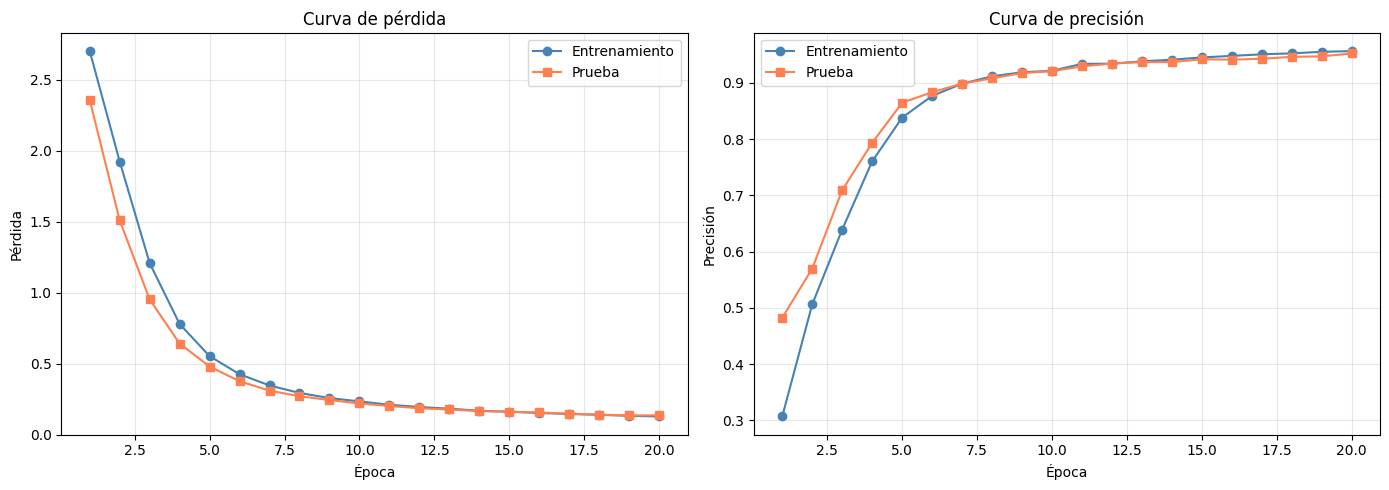

In [813]:
# definir el criterio de loss y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=LEARNING_RATE)

# entrenar el modelo
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_pt, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model_pt, test_loader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
# graficas de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# pérdida
ax1.plot(range(1, EPOCHS + 1), train_losses, marker='o', label='Entrenamiento', color='steelblue')
ax1.plot(range(1, EPOCHS + 1), test_losses, marker='s', label='Prueba', color='coral')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.set_title('Curva de pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Curva de precisión
ax2.plot(range(1, EPOCHS + 1), train_accuracies, marker='o', label='Entrenamiento', color='steelblue')
ax2.plot(range(1, EPOCHS + 1), test_accuracies, marker='s', label='Prueba', color='coral')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.set_title('Curva de precisión')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Con las curvas de pérdida podemos observar que el modelo no presenta sobreajuste ni bajoajuste, ya que tanto entrenamiento como prueba muestran una tendencia muy similar. La pérdida más significativa se observa en las primeras 5 épocas, donde el modelo aprende rápidamente a clasificar las muestras. A partir de la época 10, la curva de pérdida se estabiliza, lo que indica que el modelo converge adecuadamente.

In [814]:
# reportar el accuracy
test_loss, test_acc_pt = evaluate(model_pt, test_loader, criterion)
print(f'Precisión final en test (PyTorch): {test_acc_pt*100:.2f}%')

Precisión final en test (PyTorch): 95.24%


### 4. MLP con TensorFlow/Keras (30%)

1. Construye un MLP equivalente al anterior usando la API Sequential de Keras.
2. Compila el modelo con el optimizador y función de pérdida adecuados.
3. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
4. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

In [815]:
# construir el mismo MLP con keras
model_keras = keras.Sequential([
    layers.Input(shape=(INPUT_SIZE,)), 
    layers.Dense(HIDDEN_SIZE1, activation='relu', name='capa_oculta_1'),
    layers.Dense(HIDDEN_SIZE2, activation='relu', name='capa_oculta_2'),
    layers.Dense(NUM_CLASSES, name='capa_salida')
], name='MLP')

# ver el resumen del modelo
model_keras.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 64)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 19)             │           627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,203 (20.32 KB)

 Trainable params: 5,203 (20.32 KB)

 Non-trainable params: 0 (0.00 B)

Como optimizador utilizaremos Adam y como función de pérdida `SparseCategoricalCrossentropy` con `from_logits=True`, ya que la capa de salida no tiene activación softmax y las etiquetas están codificadas como enteros (0 a 18 en este caso particular).

In [816]:
# compilar el modelo
model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3087 - loss: 2.5336 - val_accuracy: 0.6471 - val_loss: 1.3552
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.7110 - loss: 1.1049 - val_accuracy: 0.7934 - val_loss: 0.7108
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - accuracy: 0.8139 - loss: 0.6199 - val_accuracy: 0.8571 - val_loss: 0.4666
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - accuracy: 0.8749 - loss: 0.4270 - val_accuracy: 0.8759 - val_loss: 0.3527
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.8875 - loss: 0.3328 - val_accuracy: 0.9005 - val_loss: 0.2875
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.9084 - loss: 0.2719 - val_accuracy: 0.9201 - val_loss: 0.2437
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - accuracy: 0.9342 - loss: 0.2136 - val_accuracy: 0.9243 - val_loss: 0.2122
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - accuracy: 0.9416 - loss: 0.1890 - val_accuracy: 0.91

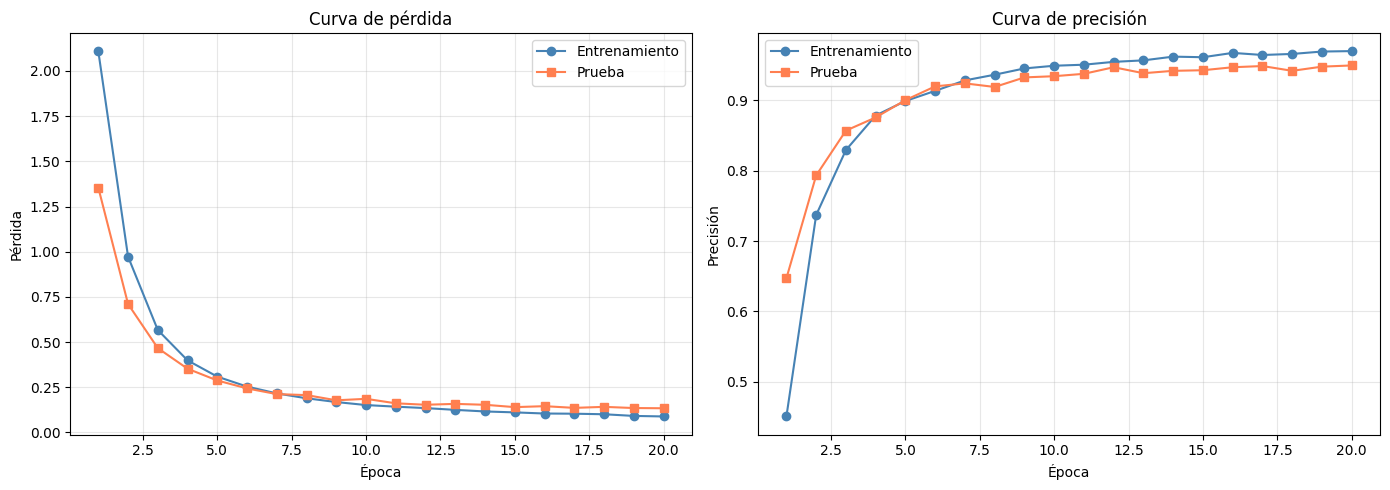

In [817]:
# entrenamiento del modelo
history = model_keras.fit(
    X_train, y_train,
    batch_size=64,
    epochs= EPOCHS,
    validation_data=(X_test, y_test),
    verbose=1
)

# gráficas de loss y accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida
ax1.plot(range(1, EPOCHS + 1), history.history['loss'], marker='o', label='Entrenamiento', color='steelblue')
ax1.plot(range(1, EPOCHS + 1), history.history['val_loss'], marker='s', label='Prueba', color='coral')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.set_title('Curva de pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Curva de precisión
ax2.plot(range(1, EPOCHS + 1), history.history['accuracy'], marker='o', label='Entrenamiento', color='steelblue')
ax2.plot(range(1, EPOCHS + 1), history.history['val_accuracy'], marker='s', label='Prueba', color='coral')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.set_title('Curva de precisión')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


El modelo con Keras muestra una tendencia muy similar a la del modelo en PyTorch, con una rápida disminución de la pérdida en las primeras épocas y una estabilización a partir de la época 10. Este modelo tampoco muestra signos de sobreajuste ni bajoajuste, lo que sugiere que la arquitectura y el proceso de entrenamiento son adecuados para este dataset.

In [818]:
# accuracy
test_loss, test_acc_keras = model_keras.evaluate(X_test, y_test, verbose=0)
print(f'Precisión final en test (Keras): {test_acc_keras*100:.2f}%')

Precisión final en test (Keras): 94.98%


### 5. Comparación de resultados (10%)

1. Genera la matriz de confusión para los modelos MLP.
2. ¿Cuáles tipos de célula son más difíciles de clasificar? ¿Son los mismos en ambos modelos?
3. Compara la precisión obtenida con PyTorch vs TensorFlow.


In [819]:
# funciones para calcular las matrices de confusión para pytorch y keras
@torch.no_grad()
def compute_confusion_matrix_pt(model, data_loader, num_classes):
    """Calcula la matriz de confusión."""
    model.eval()
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)

    for features, labels in data_loader:
        features = features.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs, 1)
        predicted = predicted.cpu()

        for t, p in zip(labels, predicted):
            confusion[t, p] += 1

    return confusion

def compute_confusion_matrix_keras(model, x_data, y_data, num_classes=10):
    """Calcula la matriz de confusión."""
    logits = model(x_data, training=False)
    predicted = tf.argmax(logits, axis=1).numpy()
    confusion = tf.math.confusion_matrix(y_data, predicted, num_classes=num_classes).numpy()
    return confusion



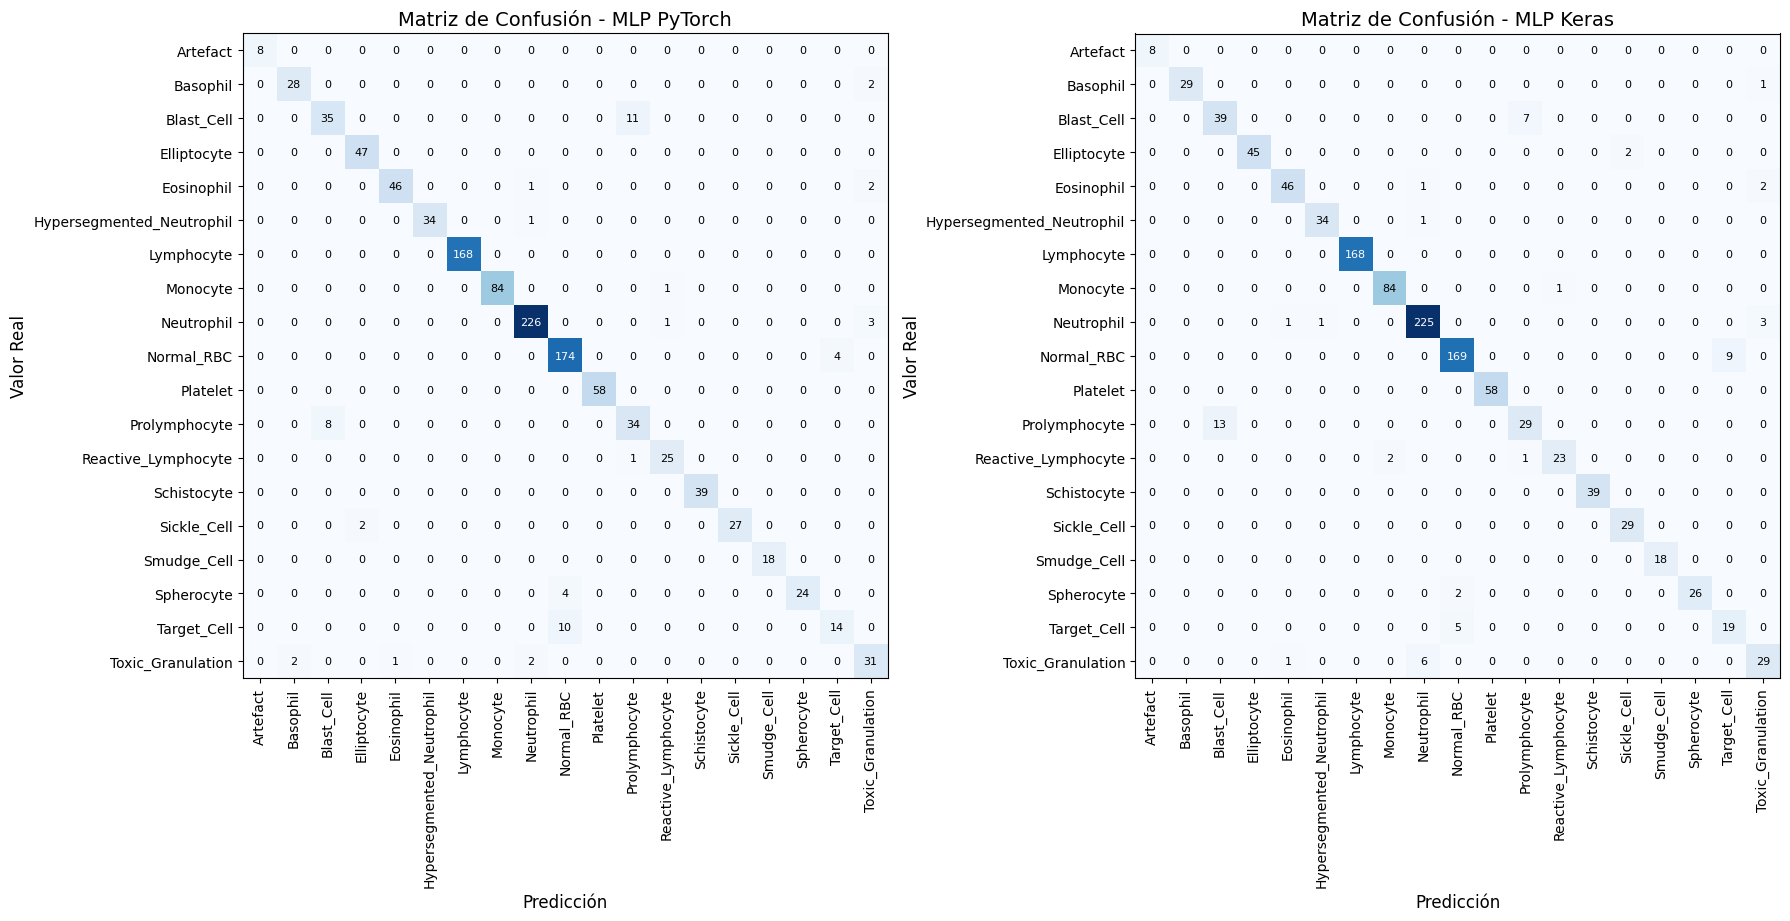

In [820]:
# obtener las matrices de confusión para ambos modelos
confusion_pt = compute_confusion_matrix_pt(model_pt, test_loader, NUM_CLASSES)
confusion_keras = compute_confusion_matrix_keras(model_keras, X_test, y_test, NUM_CLASSES)

# crear la figura y los ejes para las dos matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(18, 9)) 

matrices = [confusion_pt, confusion_keras]
titles = ['MLP PyTorch', 'MLP Keras']
classes = label_encoder.classes_
indices = np.arange(len(classes))

for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(matrix, cmap='Blues')

    ax.set_title(f'Matriz de Confusión - {title}', fontsize=14)
    ax.set_xlabel('Predicción', fontsize=12)
    ax.set_ylabel('Valor Real', fontsize=12)
    
    # añadir etiquetas de clases en los ejes
    ax.set_xticks(indices)
    ax.set_xticklabels(classes, rotation=90)
    ax.set_yticks(indices)
    ax.set_yticklabels(classes)
    
    thresh = matrix.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = matrix[i, j].item() if hasattr(matrix[i, j], 'item') else matrix[i, j]
            color = 'white' if val > thresh else 'black'
            ax.text(j, i, int(val), ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

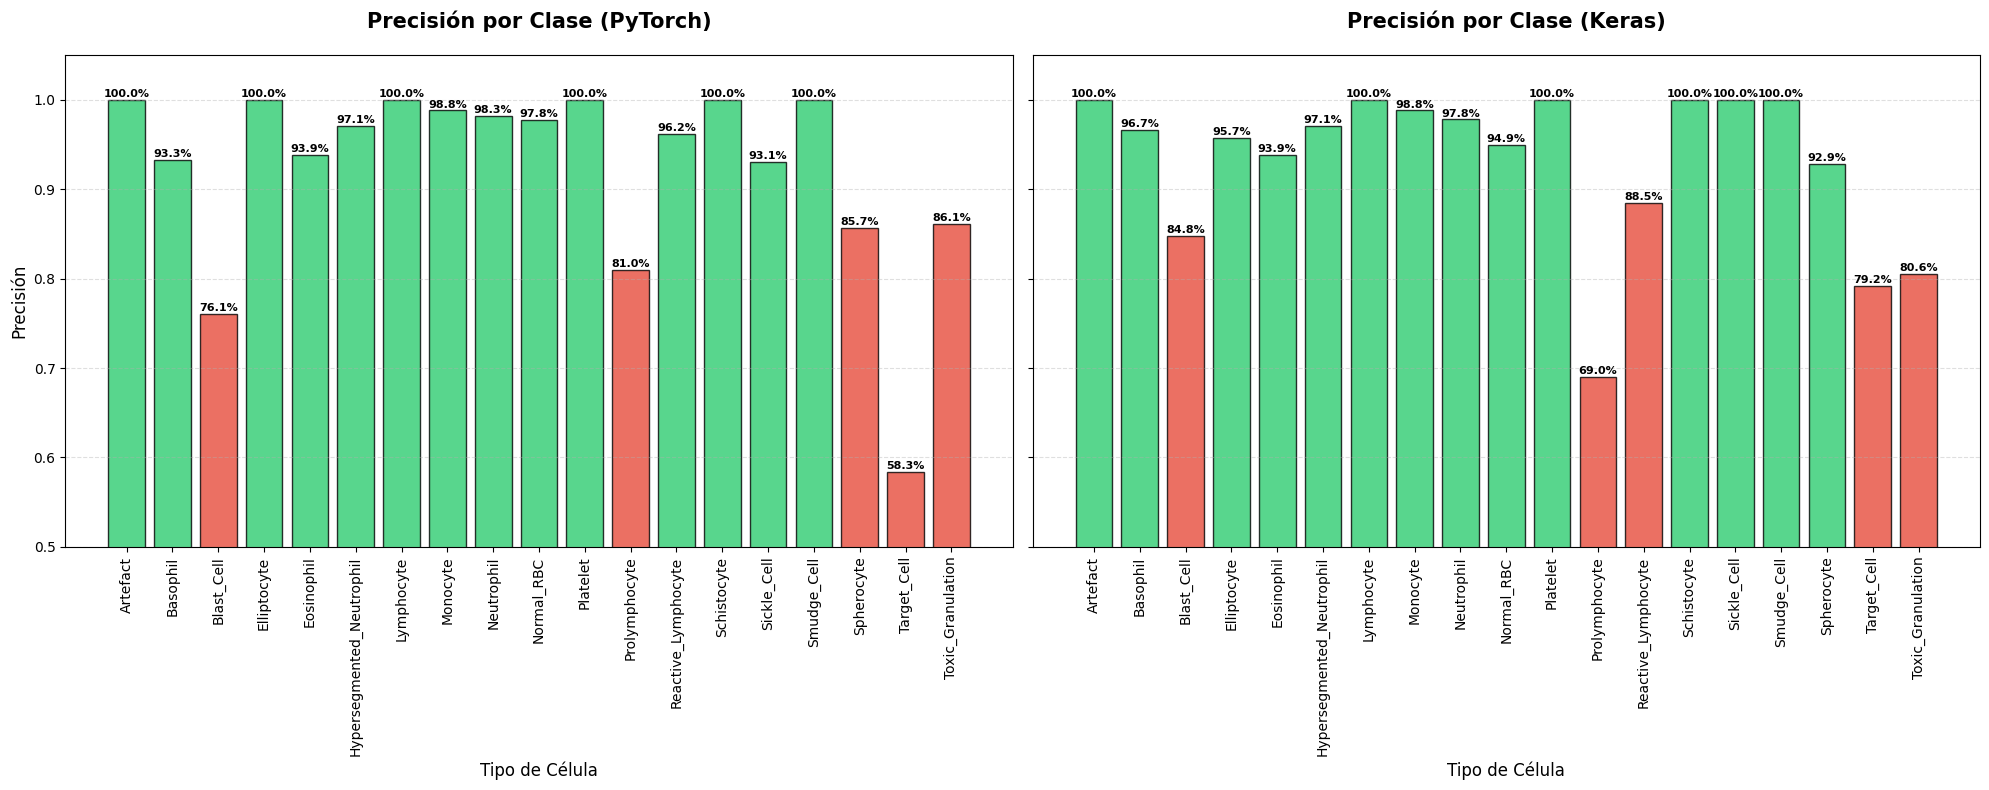

In [840]:
# calcular la precisión por clase como el número de predicciones correctas entre el total de muestras de cada clase
diag_pt = confusion_pt.diag().cpu().numpy()
sum_pt = confusion_pt.sum(dim=1).cpu().numpy()
per_class_accuracy_pt = diag_pt / sum_pt

per_class_accuracy_keras = np.diag(confusion_keras) / confusion_keras.sum(axis=1)

# graficar la precisión por clase para ambos modelos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
clases = label_encoder.classes_
x_indices = np.arange(len(clases))

def plot_accuracy_bars(ax, accuracies, title):
    # definir los colores según precisión - verde para >95% y rojo para <=95%
    colors = ['#2ecc71' if acc > 0.9 else '#e74c3c' for acc in accuracies]
    
    # grafico de barras para cada clase
    bars = ax.bar(x_indices, accuracies, color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=15, pad=20, fontweight='bold')
    ax.set_xlabel('Tipo de Célula', fontsize=12)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(clases, rotation=90, fontsize=10)
    ax.set_ylim(0.5, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # etiquetas de porcentaje sobre cada barra
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{acc:.1%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# obtener cada subplot y graficar
plot_accuracy_bars(ax1, per_class_accuracy_pt, 'Precisión por Clase (PyTorch)')
plot_accuracy_bars(ax2, per_class_accuracy_keras, 'Precisión por Clase (Keras)')
ax1.set_ylabel('Precisión', fontsize=12)
plt.tight_layout()
plt.show()

In [821]:
# presición en ambos modelos
print(f'Precisión final en test (PyTorch): {test_acc_pt*100:.2f}%')
print(f'Precisión final en test (Keras): {test_acc_keras*100:.2f}%')

Precisión final en test (PyTorch): 95.24%
Precisión final en test (Keras): 94.98%


Observando las matrices de confusión de ambos modelos y los gráficos de barra con la precisión por clase, podemos concluir que ambos modelos presentan dificultades en clasificar correctamente las clases **Blast_Cell**, **Prolymphocyte**, **Target_Cell** y **Toxic_Granulation**, las cuales no logran superar el 90% de accuracy en ninguna de las dos implementaciones. Dichas clases tienen una cantidad de muestras relativamente baja en comparación con las clases mayoritarias (menos de 300 muestras cada una). Esta dificultad en la clasificación se puede atribuir tanto al reducido volumen de muestras como a una posible similitud morfológica entre las células de las clases identificadas, lo que genera un solapamiento en el espacio de características que confunde a ambos modelos.

A nivel individual, se observan diferencias menores: el modelo en PyTorch mostró mayor dificultad con los **Spherocytes** (85.7%), mientras que el de Keras no sobrepasa el 90% de accuracy en los **Reactive_Lymphocytes** (88.5%).

En general, ambos modelos presentan un desempeño muy similar, con una precisión global de alrededor del 95%, siendo el modelo de PyTorch el que muestra una ligera ventaja en la métrica global. 

Es importante destacar que ambos modelos tienen dificultades para clasificar correctamente ciertas clases minoritarias, lo que sugiere que podrían beneficiarse de técnicas adicionales como el balanceo de clases o el uso de arquitecturas más complejas.

In [2]:
!jupyter nbconvert --to pdf e.laverdeb@uniandes.edu.co_lab7.ipynb --output e.laverdeb@uniandes.edu.co_lab7.pdf

[NbConvertApp] Converting notebook e.laverdeb@uniandes.edu.co_lab7.ipynb to pdf
[NbConvertApp] Support files will be in e.laverdeb@uniandes.edu.co_lab7_files/
[NbConvertApp] Making directory ./e.laverdeb@uniandes.edu.co_lab7_files
[NbConvertApp] Writing 102437 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 472435 bytes to e.laverdeb@uniandes.edu.co_lab7.pdf
